# Dataset Exploration & Visual Verification

This notebook verifies and visualizes sample image-mask pairs from each supported dataset:
1. **CConCrack**
2. **NCCD-PF_Dataset**
3. **DeepCrack**
4. **CRACK500**

It inspects **image/mask alignments**, **pixel value conventions** (Background: 0 / Crack: 255), and **official split counts**.

In [1]:
import sys
from pathlib import Path
# Ensure project root is in sys.path
project_root = Path.cwd().parent.parent if Path.cwd().name == 'data_handlers' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from crack_seg import config
from crack_seg.data_handlers.dataset_loaders import (
    load_dataset_partitions,
    get_train_val_test_datasets,
)
from crack_seg.data_handlers.class_imbalance import compute_crack_pixel_proportion

print(f"Data Root: {config.DATA_ROOT.resolve()}")

Data Root: C:\Users\abinashm\OneDrive - University of Nevada, Reno\phd research\paper submission\crack-segmentation\data


## 1. Inspect Dataset Partition Counts & Conventions
Verify that every dataset loads with valid image and mask pairings.

In [2]:
datasets = ["CConCrack", "NCCD-PF_Dataset", "DeepCrack", "CRACK500"]

for ds_name in datasets:
    partitions = load_dataset_partitions(ds_name, data_root=config.DATA_ROOT)
    total = sum(len(v) for v in partitions.values())
    print(f"\nDataset: {ds_name} (Total: {total:,} pairs)")
    for part_name, samples in partitions.items():
        print(f"  - {part_name:<6}: {len(samples):,}")


Dataset: CConCrack (Total: 10,995 pairs)
  - train : 9,899
  - test  : 1,096

Dataset: NCCD-PF_Dataset (Total: 689 pairs)
  - all   : 689

Dataset: DeepCrack (Total: 537 pairs)
  - train : 300
  - test  : 237

Dataset: CRACK500 (Total: 3,868 pairs)
  - train : 2,146
  - val   : 398
  - test  : 1,324


## 2. Visual Alignment Check Across All Datasets
Plot sample images, masks, and transparent red crack overlays to ensure zero image/mask reversal.

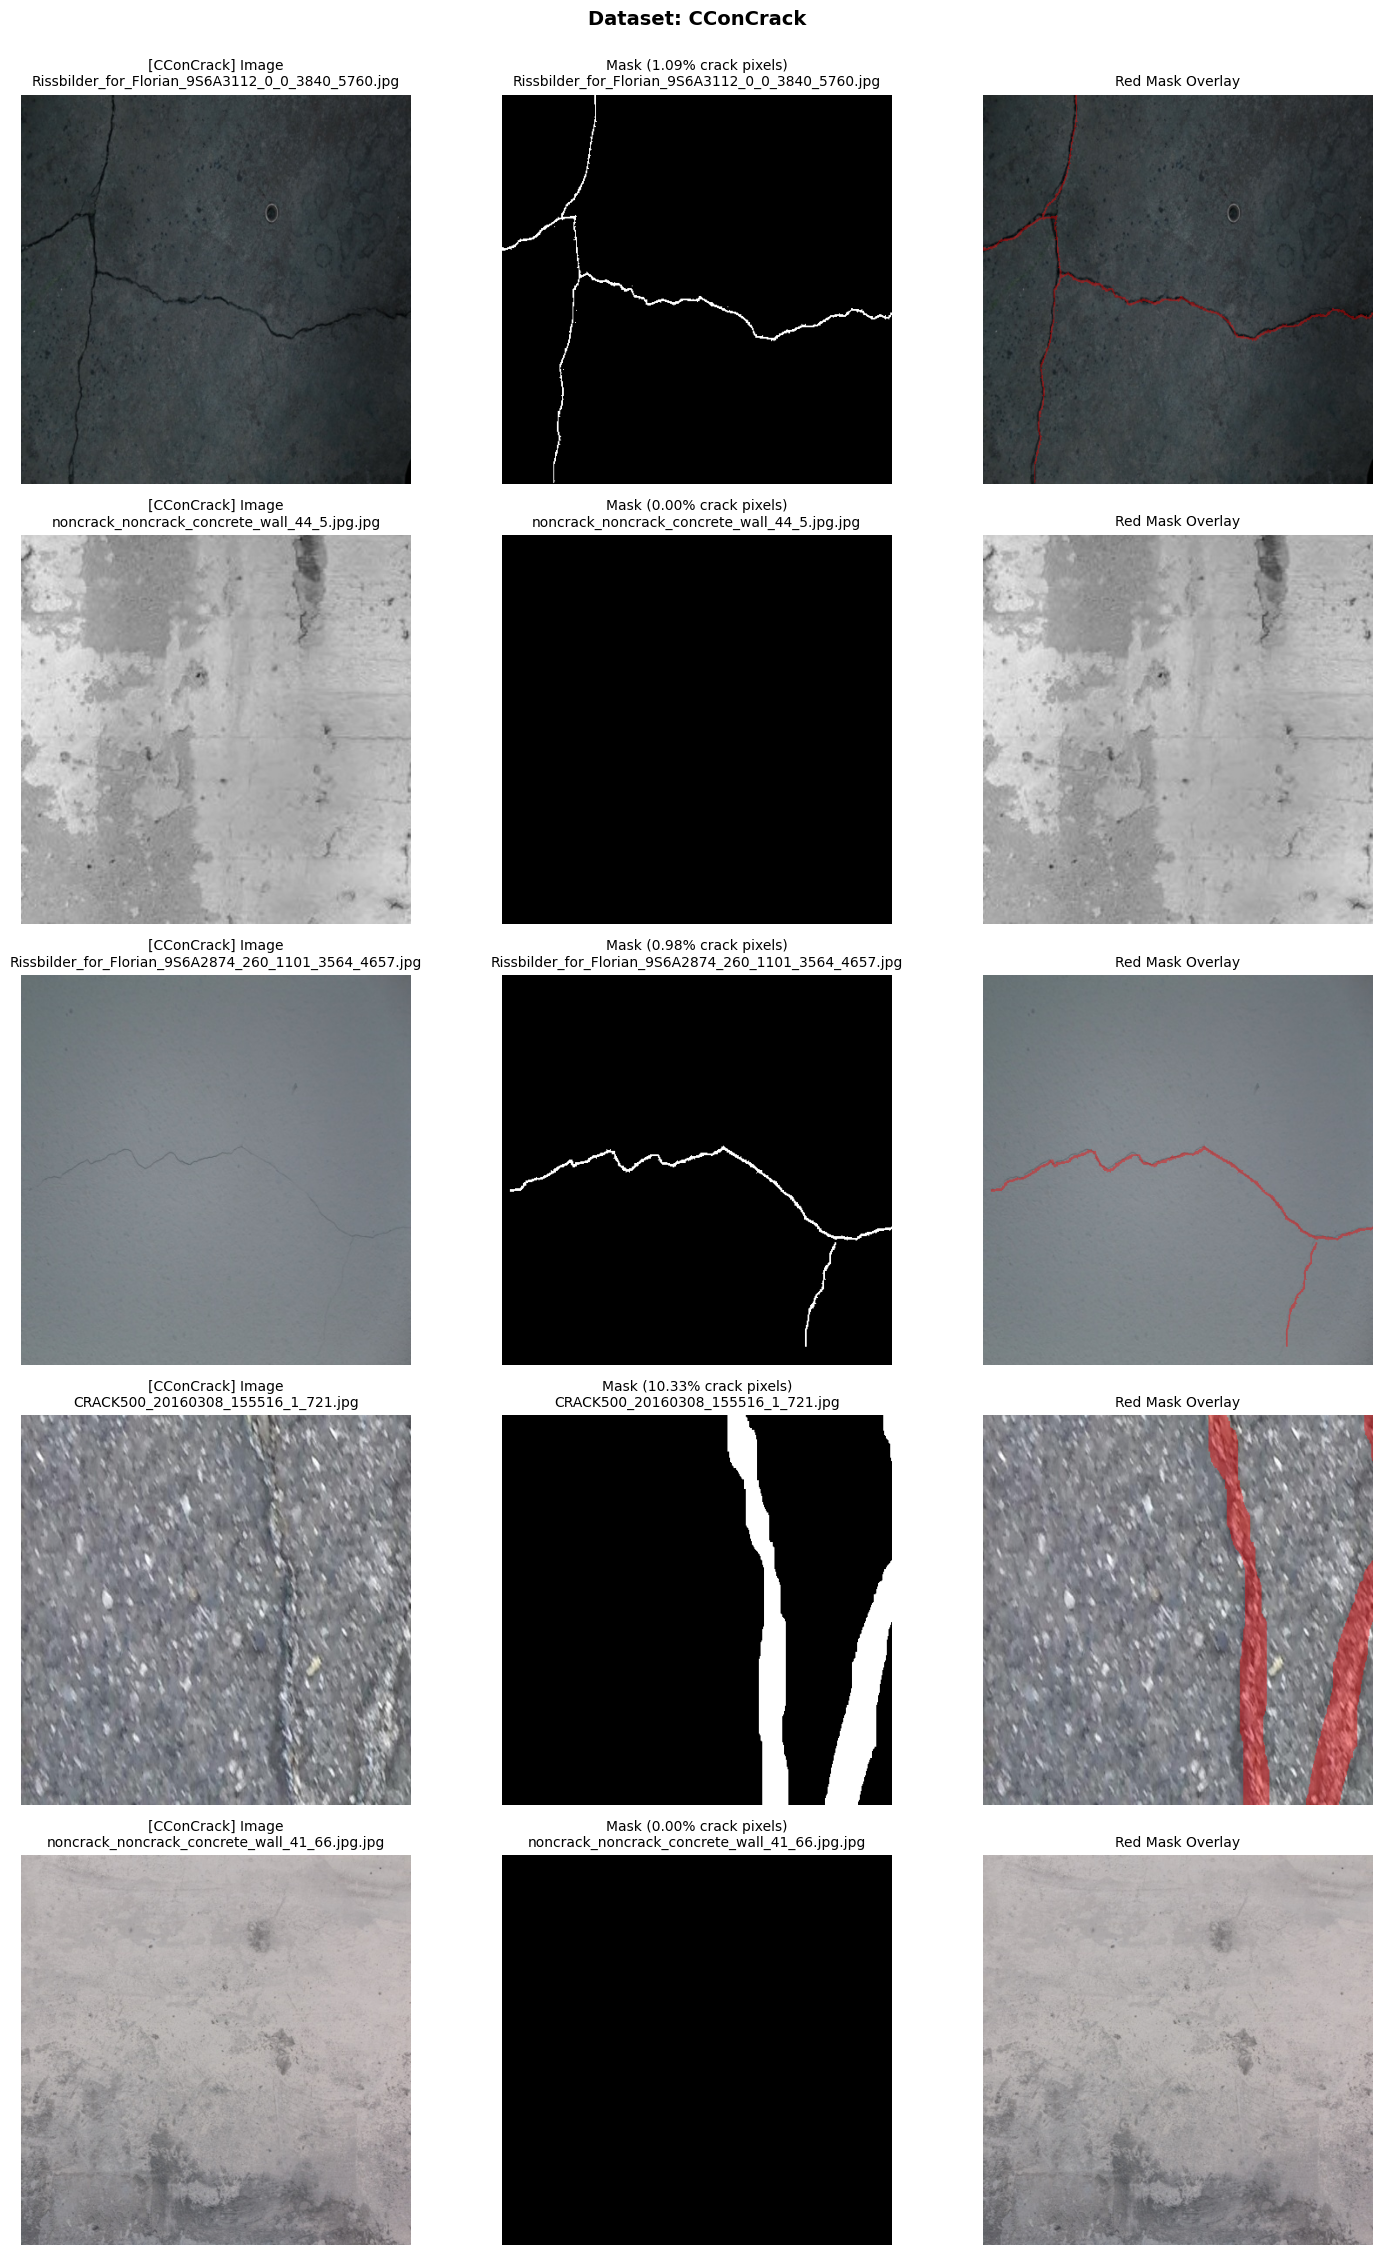

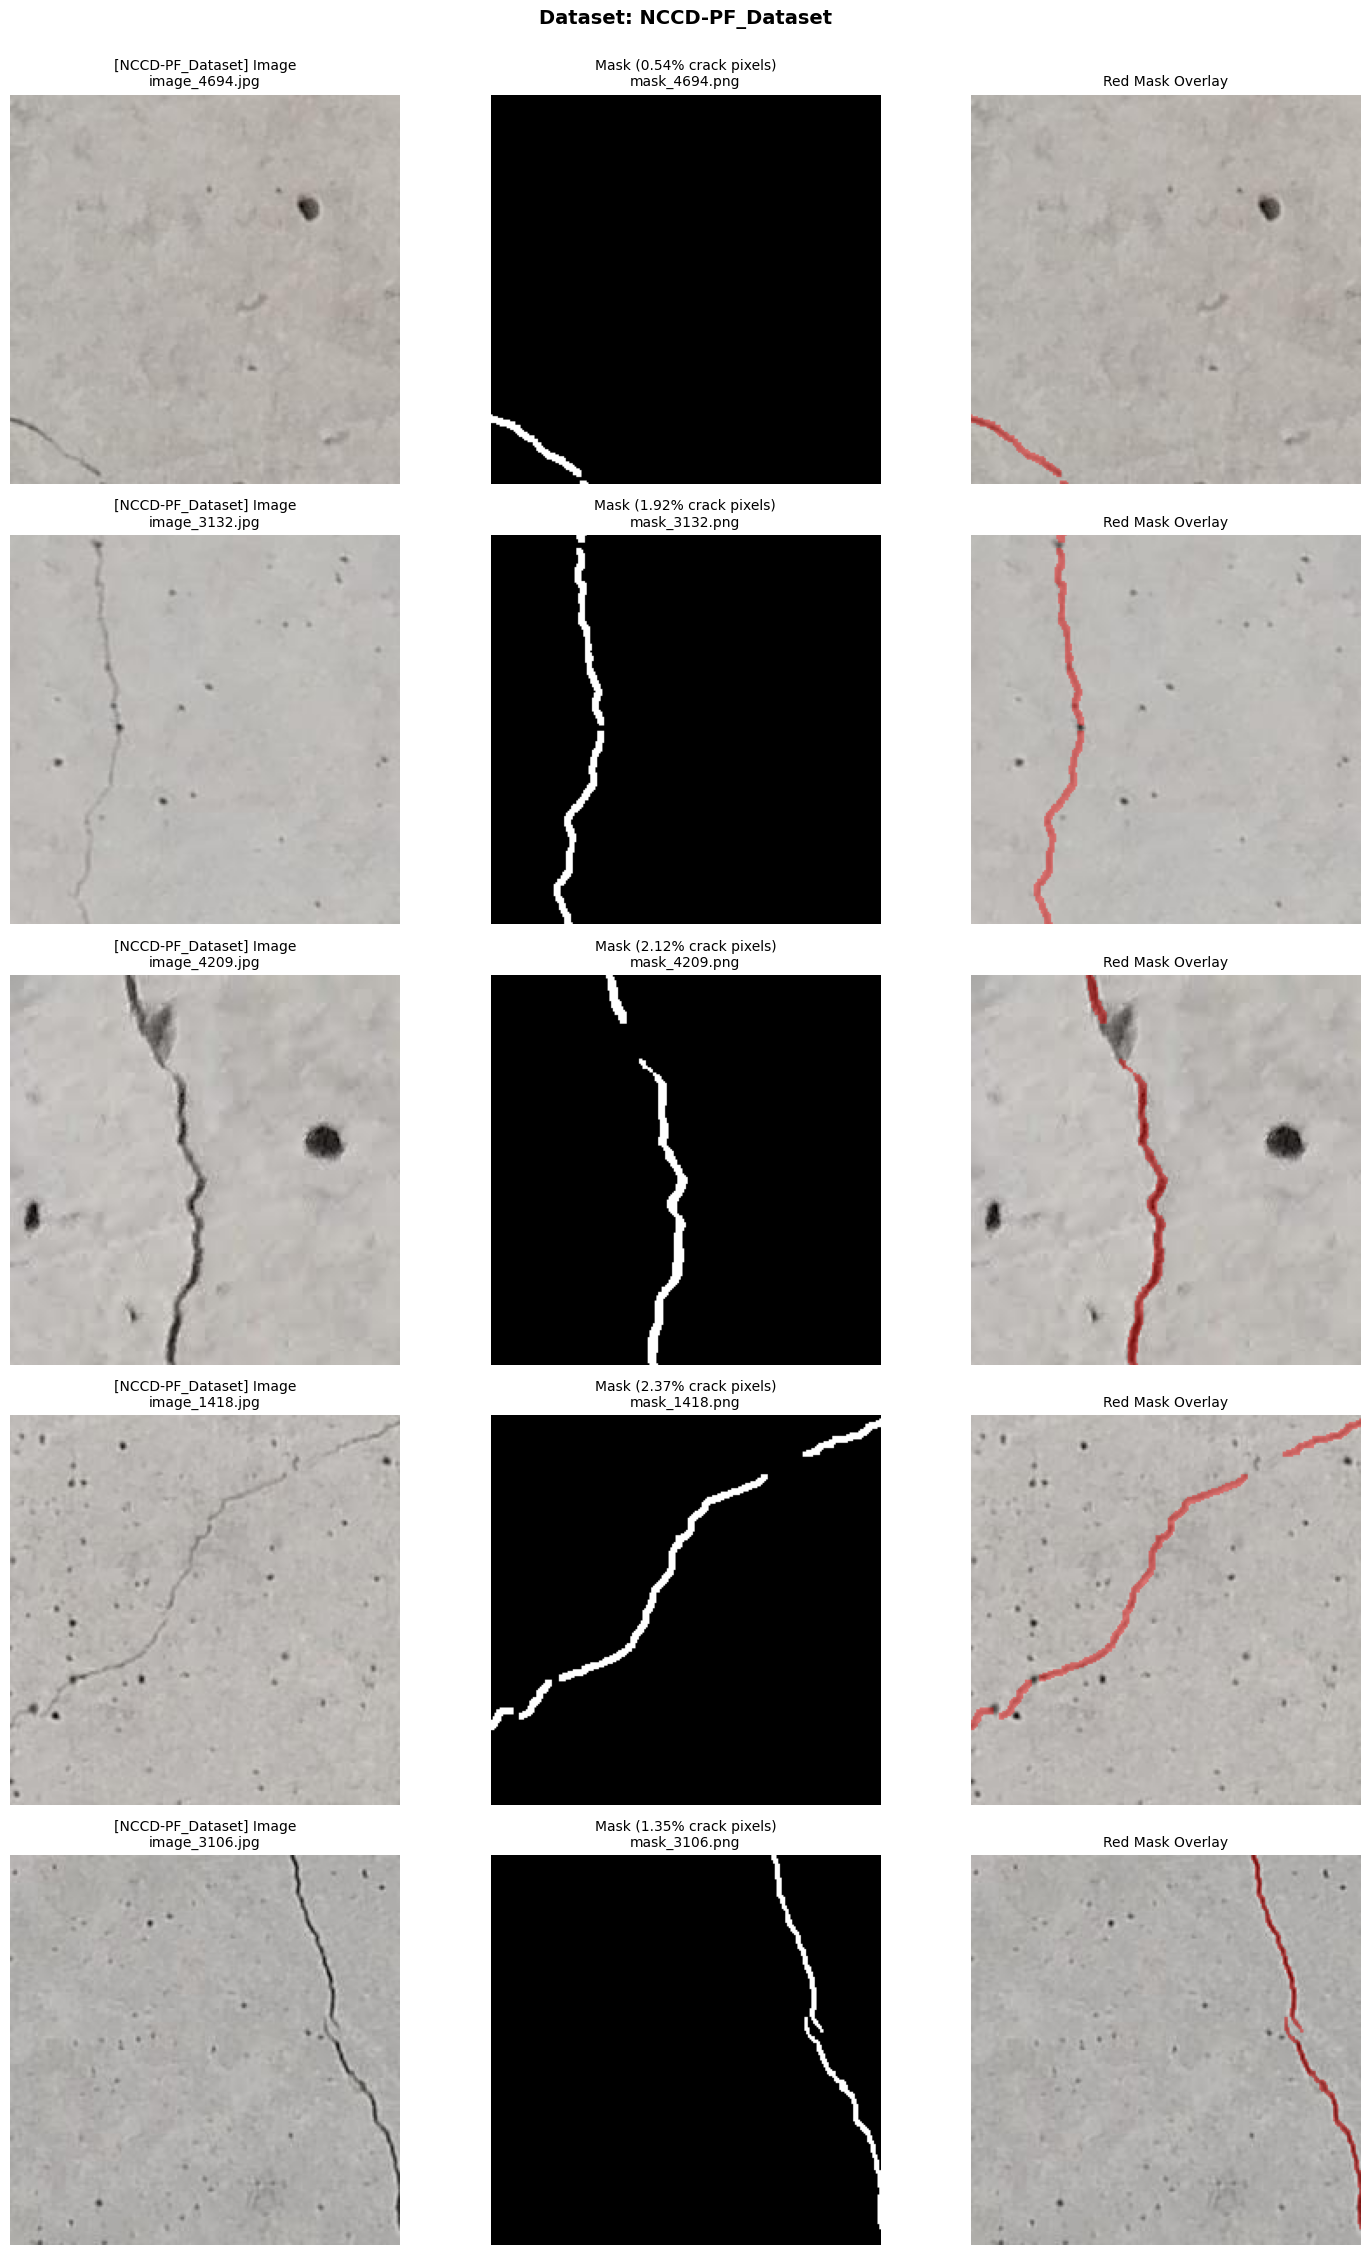

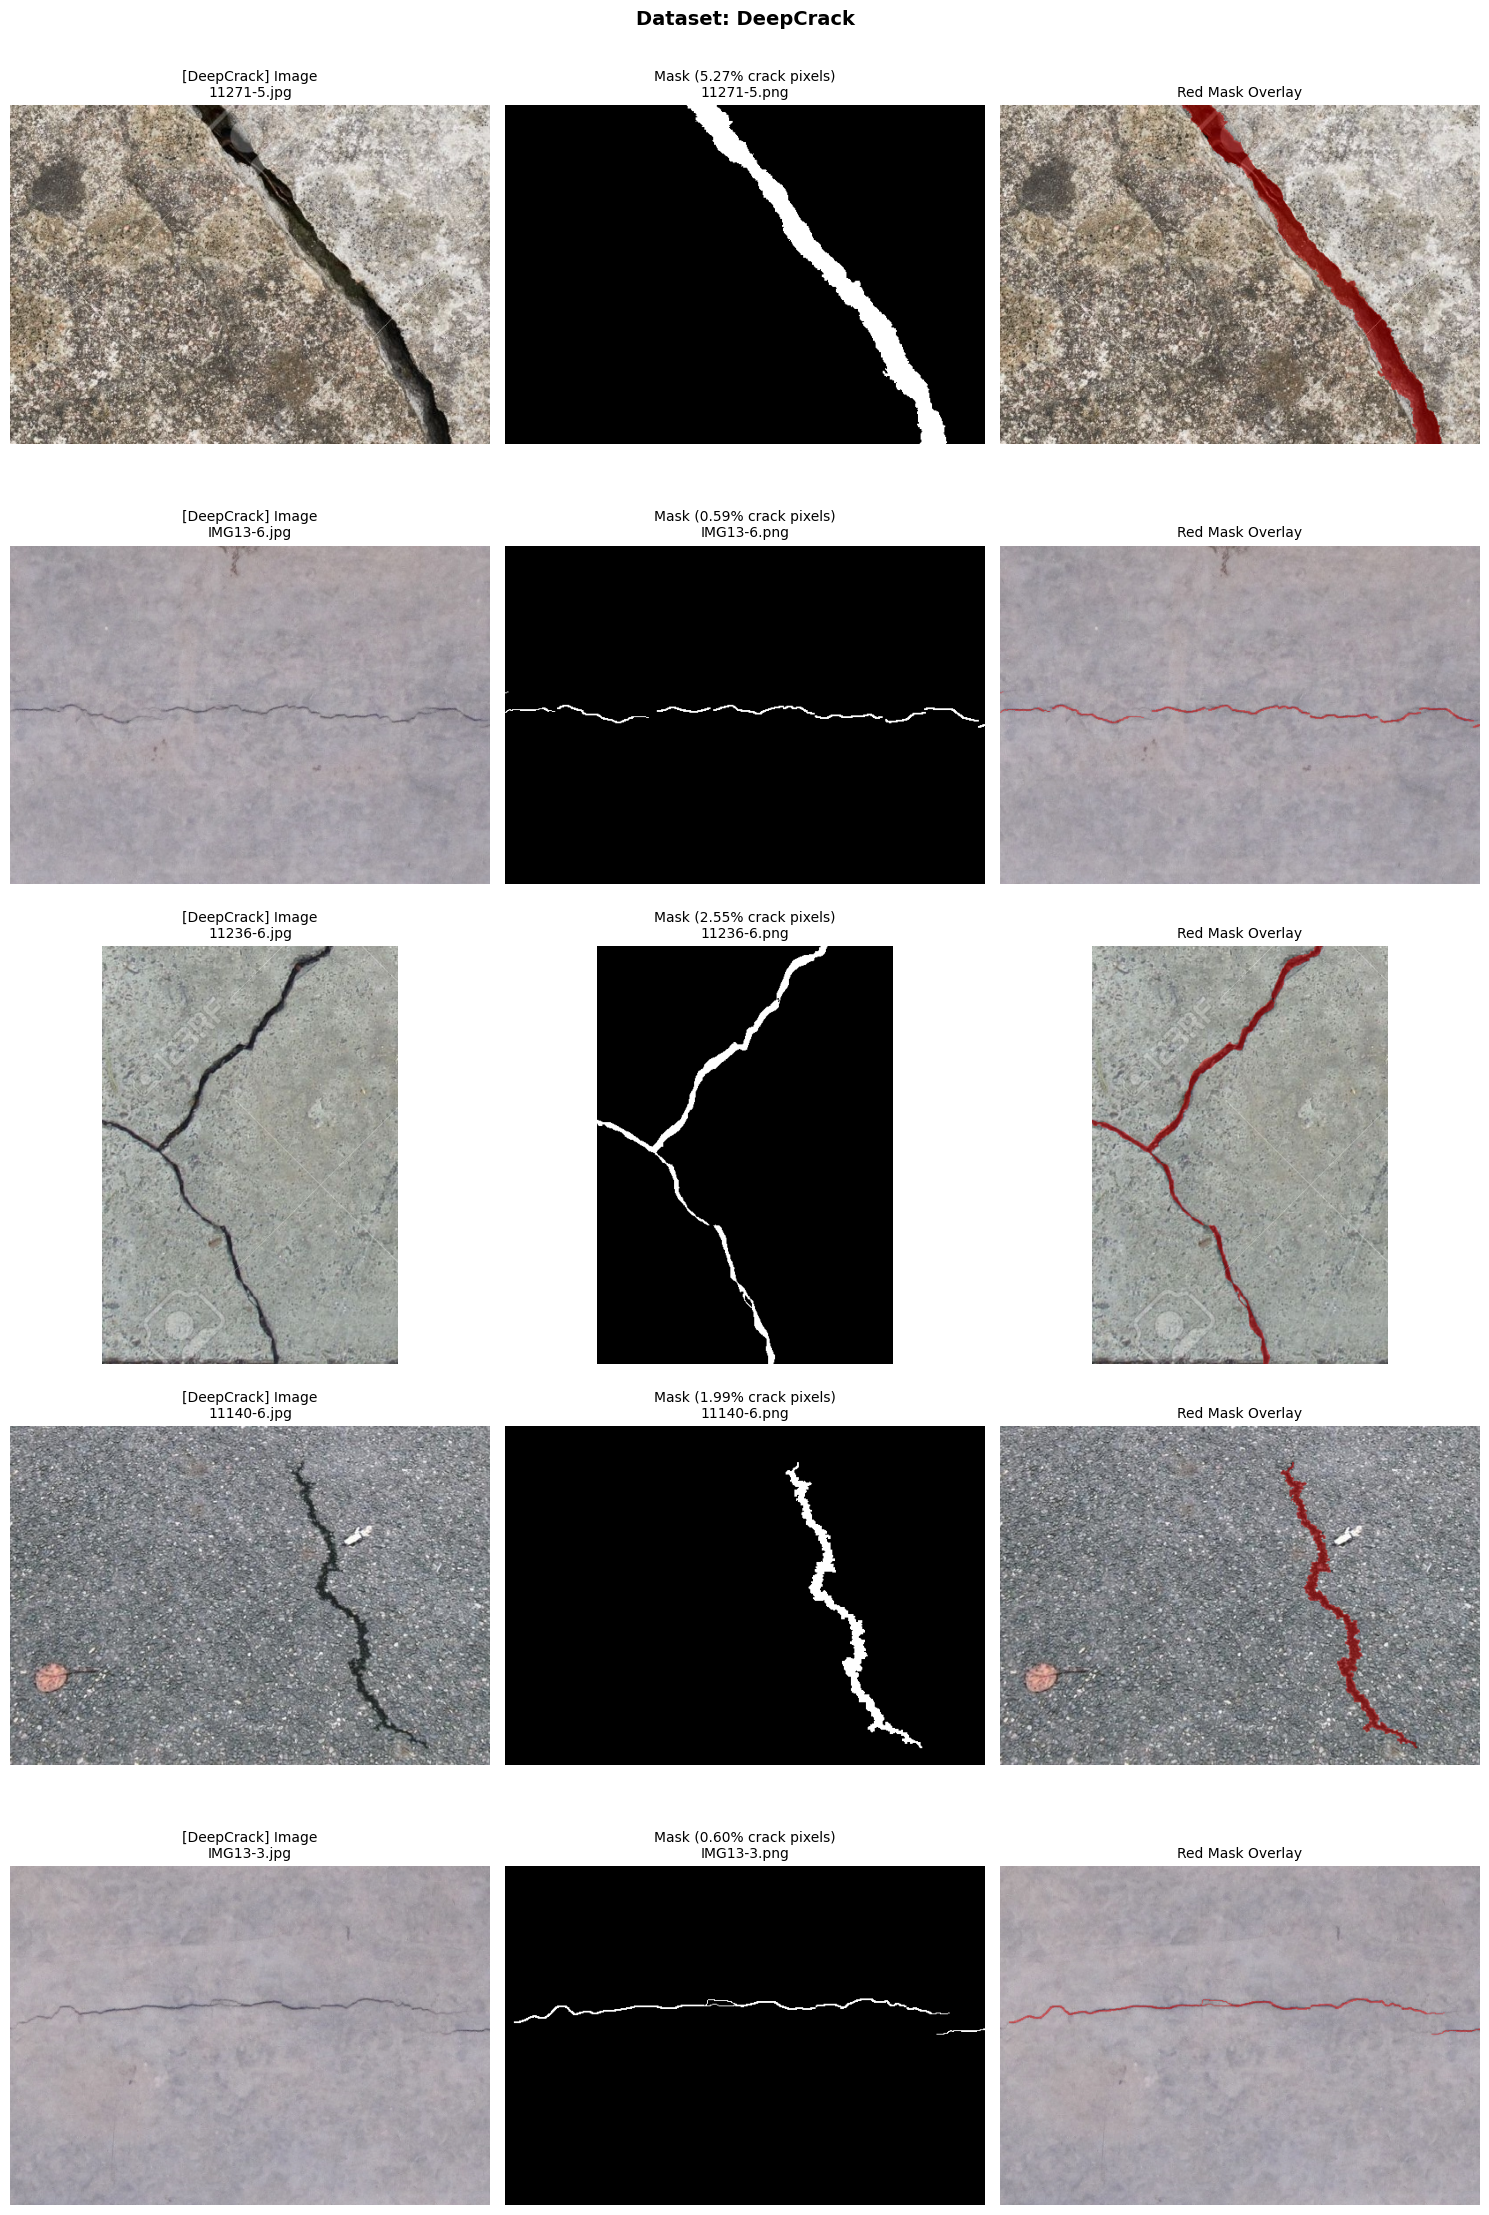

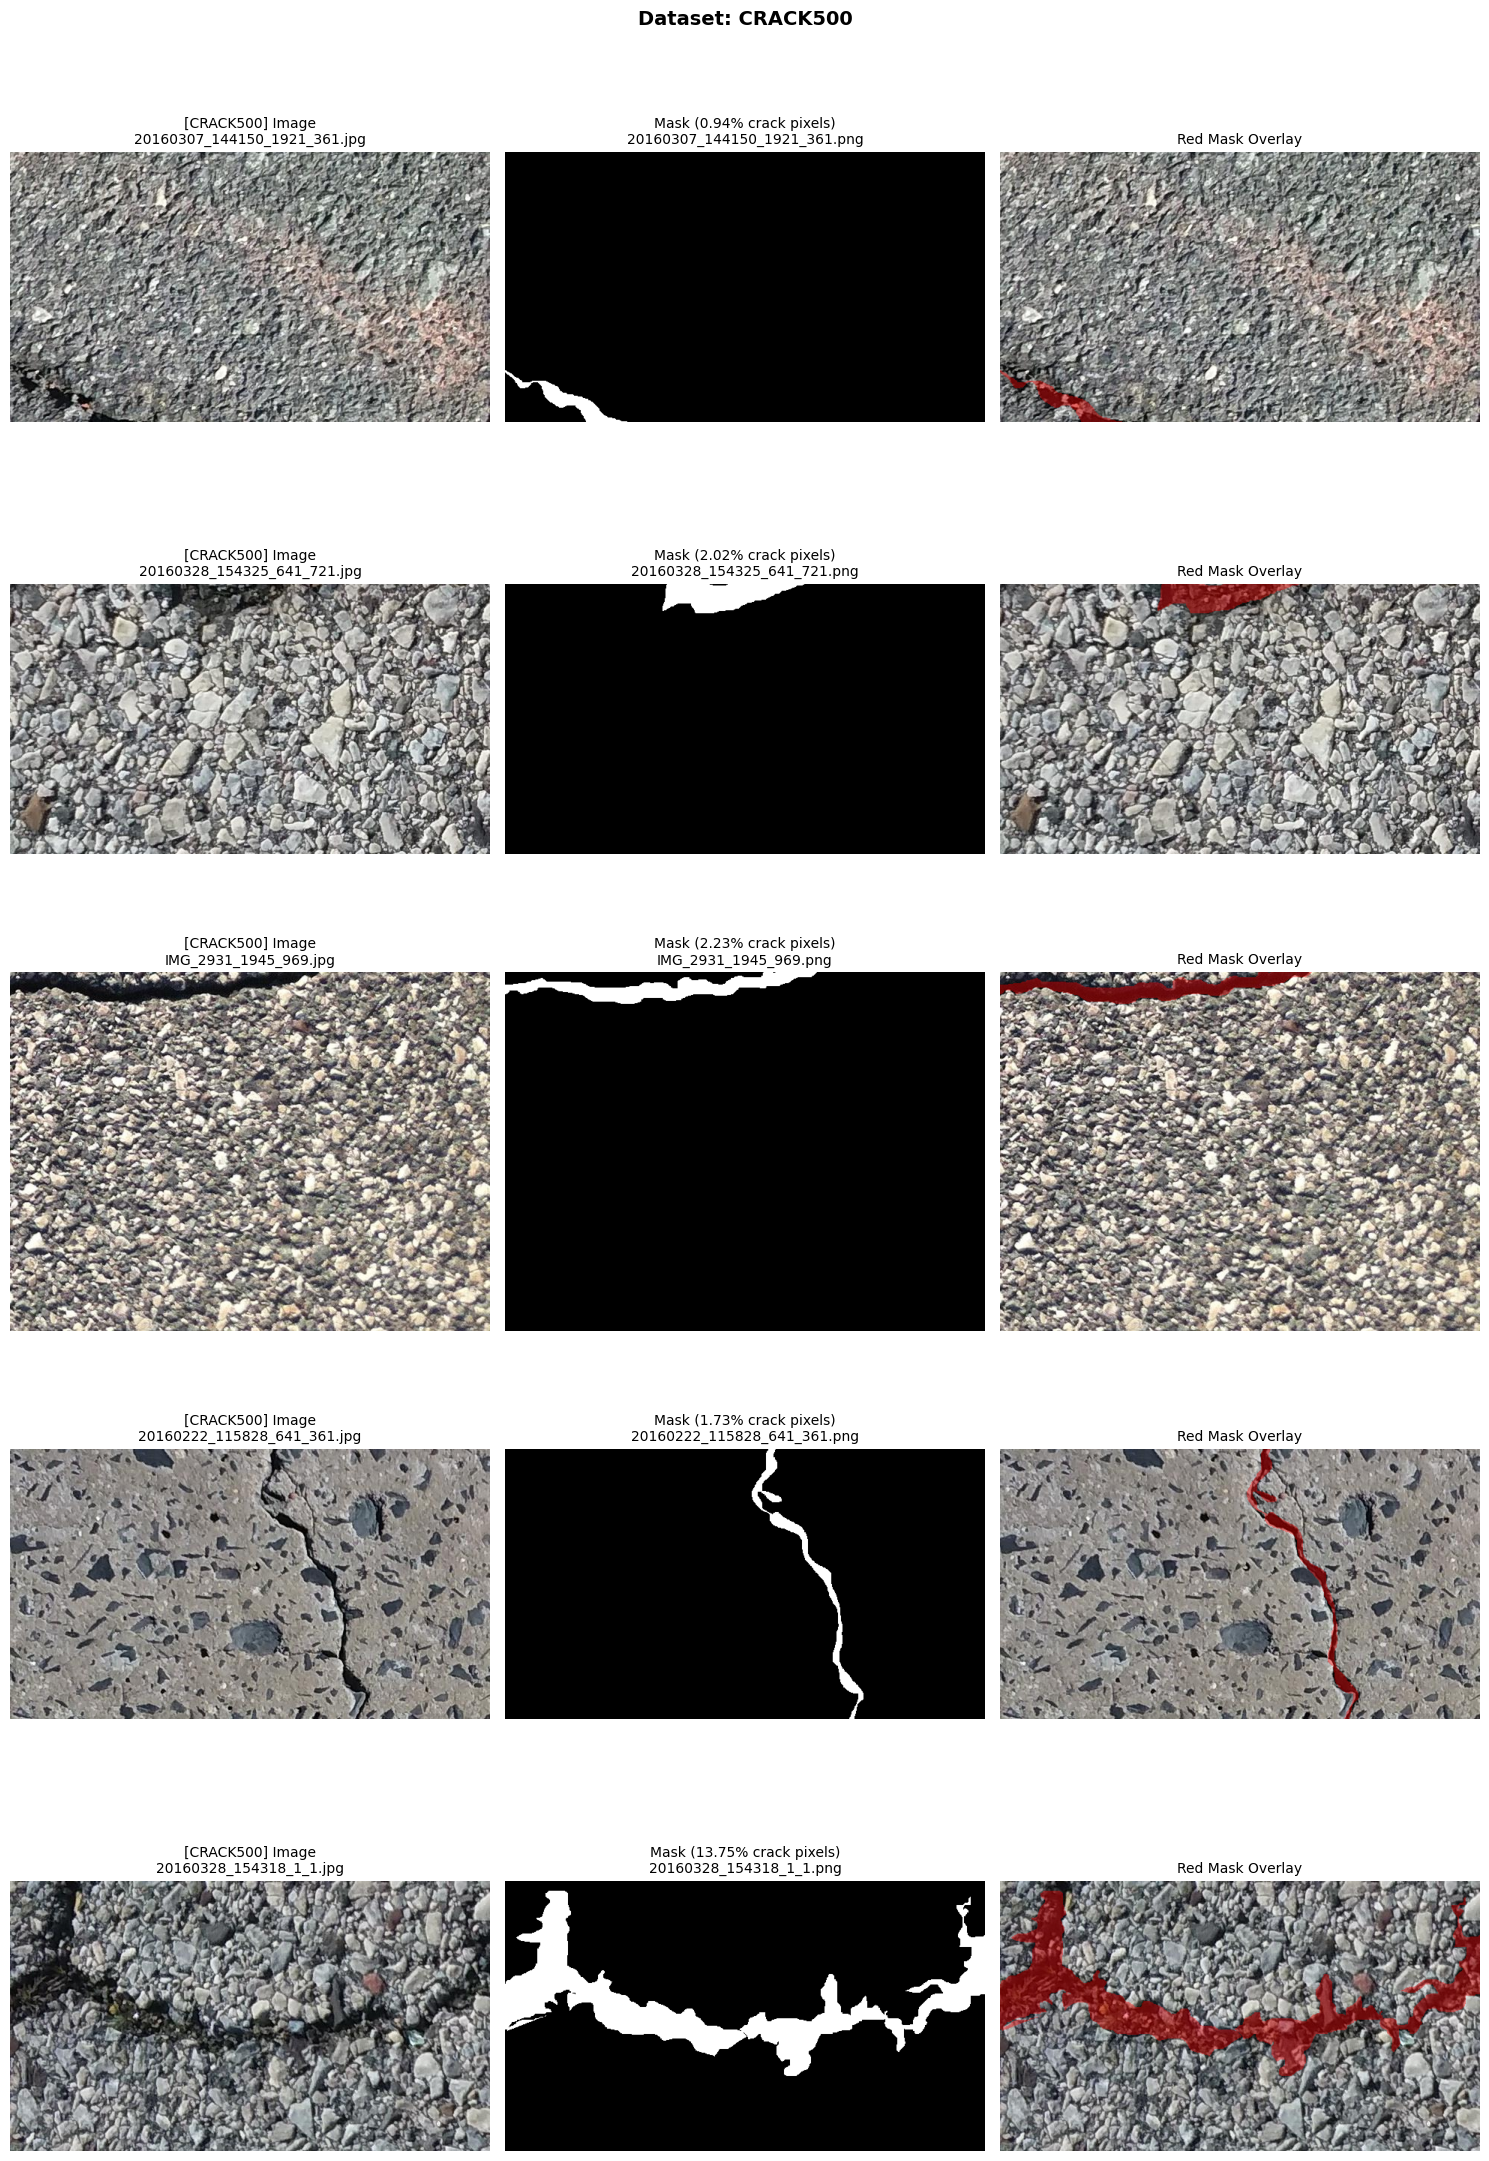

In [4]:
num_samples_per_dataset = 5

for ds_name in datasets:
    partitions = load_dataset_partitions(ds_name, data_root=config.DATA_ROOT)
    all_samples = []
    for v in partitions.values():
        all_samples.extend(v)
    
    rng = np.random.default_rng(42)
    selected = rng.choice(len(all_samples), size=min(num_samples_per_dataset, len(all_samples)), replace=False)
    
    fig, axes = plt.subplots(len(selected), 3, figsize=(15, 4.5 * len(selected)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i, idx in enumerate(selected):
        img_path, mask_path = all_samples[int(idx)]
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        mask_arr = (np.array(mask) >= config.MASK_THRESHOLD).astype(np.uint8)
        
        # Column 0: Original Photo
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"[{ds_name}] Image\n{img_path.name}", fontsize=10)
        axes[i, 0].axis("off")
        
        # Column 1: Ground Truth Mask
        axes[i, 1].imshow(mask_arr * 255, cmap="gray")
        crack_pct = np.mean(mask_arr) * 100
        axes[i, 1].set_title(f"Mask ({crack_pct:.2f}% crack pixels)\n{mask_path.name}", fontsize=10)
        axes[i, 1].axis("off")
        
        # Column 2: Red Mask Overlay on Image
        img_arr = np.array(img).copy()
        if img_arr.shape[:2] != mask_arr.shape[:2]:
            mask_resized = np.array(Image.fromarray(mask_arr).resize((img_arr.shape[1], img_arr.shape[0]), Image.Resampling.NEAREST))
        else:
            mask_resized = mask_arr
            
        overlay = img_arr.copy()
        overlay[mask_resized > 0] = [255, 0, 0]  # Red overlay for crack
        blended = (0.6 * img_arr + 0.4 * overlay).astype(np.uint8)
        
        axes[i, 2].imshow(blended)
        axes[i, 2].set_title("Red Mask Overlay", fontsize=10)
        axes[i, 2].axis("off")
        
    fig.suptitle(f"Dataset: {ds_name}", fontsize=14, fontweight="bold", y=1.00)
    fig.tight_layout()
    plt.show()

## 3. Class Imbalance Report Across All Datasets
Measure the exact foreground (crack) to background pixel distribution.

In [5]:
for ds_name in datasets:
    partitions = load_dataset_partitions(ds_name, data_root=config.DATA_ROOT)
    mask_paths = [mask_p for v in partitions.values() for _, mask_p in v]
    
    # Compute over sample subset for fast summary
    sample_masks = mask_paths[:100]
    res = compute_crack_pixel_proportion(mask_paths=sample_masks)
    print(f"[{ds_name}] (100 samples) -> Crack Ratio: {res['crack_ratio']*100:.3f}% | Background: {res['background_ratio']*100:.3f}%")

[CConCrack] (100 samples) -> Crack Ratio: 1.700% | Background: 98.300%
[NCCD-PF_Dataset] (100 samples) -> Crack Ratio: 1.490% | Background: 98.510%
[DeepCrack] (100 samples) -> Crack Ratio: 3.716% | Background: 96.284%
[CRACK500] (100 samples) -> Crack Ratio: 1.952% | Background: 98.048%
